In [1]:
import sys
import os
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from pycgp_finalclass.Config import CGPConfig
from pycgp_finalclass.ES import ES
from pycgp_finalclass.Evaluator import EvaluatorSin, Binary_Classifier, Regressor, MultiClassClassifier,Binary_Regressor
from pycgp_finalclass.Node import Node
from pycgp_finalclass.Mutation import Golden_mutation
from pycgp_finalclass.Function import Func
from pycgp_finalclass.Function_library import *
from pycgp_finalclass.Genome import CGPGenome

In [2]:
def build_funcLib(): #Define the function used
    return [Func(f_sum, 'sum', 2, 0),
            Func(f_aminus, 'aminus', 2, 0),
            Func(f_mult, 'mult', 2, 0),
            #Func(f_exp, 'exp', 2, 0),
            Func(f_abs, 'abs', 1, 0),
            Func(f_sqrt, 'sqrt', 1, 0),
            Func(f_sqrtxy, 'sqrtxy', 2, 0),
            Func(f_squared, 'squared', 1, 0),
            Func(f_pow, 'pow', 2, 0),
            Func(f_one, 'one', 0, 0),
            Func(f_zero, 'zero', 0, 0),
            Func(f_const, 'const', 0, 1),
            Func(f_inv, 'inv', 1, 0),
            Func(f_gt, 'gt', 2, 0),
            #Func(f_asin, 'asin', 1, 0),
            #Func(f_acos, 'acos', 1, 0),
            #Func(f_atan, 'atan', 1, 0),
            #Func(f_sin, 'sin', 1, 0),
            Func(f_min, 'min', 2, 0),
            Func(f_max, 'max', 2, 0),
            Func(f_round, 'round', 1, 0),
            Func(f_floor, 'floor', 1, 0),
            Func(f_ceil, 'ceil', 1, 0)
            ]
functions = build_funcLib()

Starting fitness 0.1787


Early Stop at Gen 1353:  14%|█▎        | 1353/10000 [04:28<28:39,  5.03gen/s]



Best Train fitness achieved: 0.4047

Test fitness: 0.3176
n6 = pow(x3, x2)
n7 = gt(x5, n6)
n8 = abs(n6)
n9 = aminus(n6, n7)
n10 = sqrt(x2)
n11 = max(x2, x2)
n12 = ceil(n9)
n13 = aminus(x5, n8)
n14 = pow(n13, n11)
n15 = min(x3, n11)
n16 = max(n14, n11)
n17 = sqrt(n14)
n18 = min(n9, n14)
n19 = inv(n10)
n20 = gt(n11, x5)
n21 = one()
n22 = gt(x1, n14)
n23 = sqrtxy(n20, n9)
n24 = sqrtxy(n15, n10)
n25 = zero()
n26 = zero()
n27 = pow(n7, n13)
n28 = min(x1, x0)
n29 = sqrtxy(x4, n15)
n30 = pow(n7, n18)
n31 = gt(x2, n16)
n32 = sqrtxy(n16, n17)
n33 = floor(n10)
n34 = squared(x4)
n35 = sqrtxy(x4, x1)
Outputs: n7, n24, n9, n22

Unrolled output expression 0:
gt(x5, pow(x3, x2))
Unrolled output expression 1:
sqrtxy(min(x3, max(x2, x2)), sqrt(x2))
Unrolled output expression 2:
aminus(pow(x3, x2), gt(x5, pow(x3, x2)))
Unrolled output expression 3:
gt(x1, pow(aminus(x5, abs(pow(x3, x2))), max(x2, x2)))



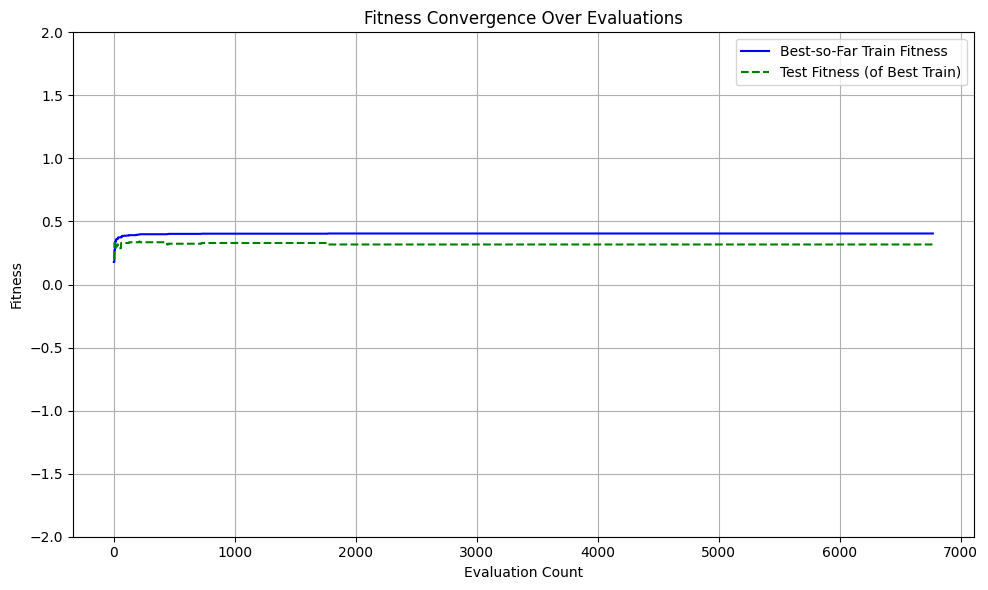

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


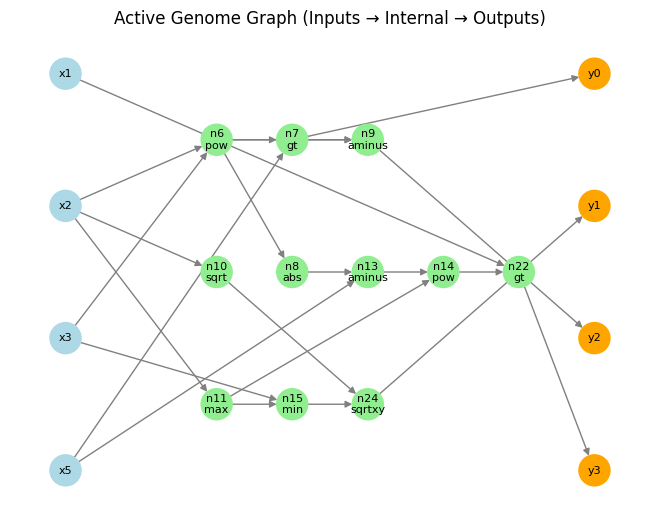

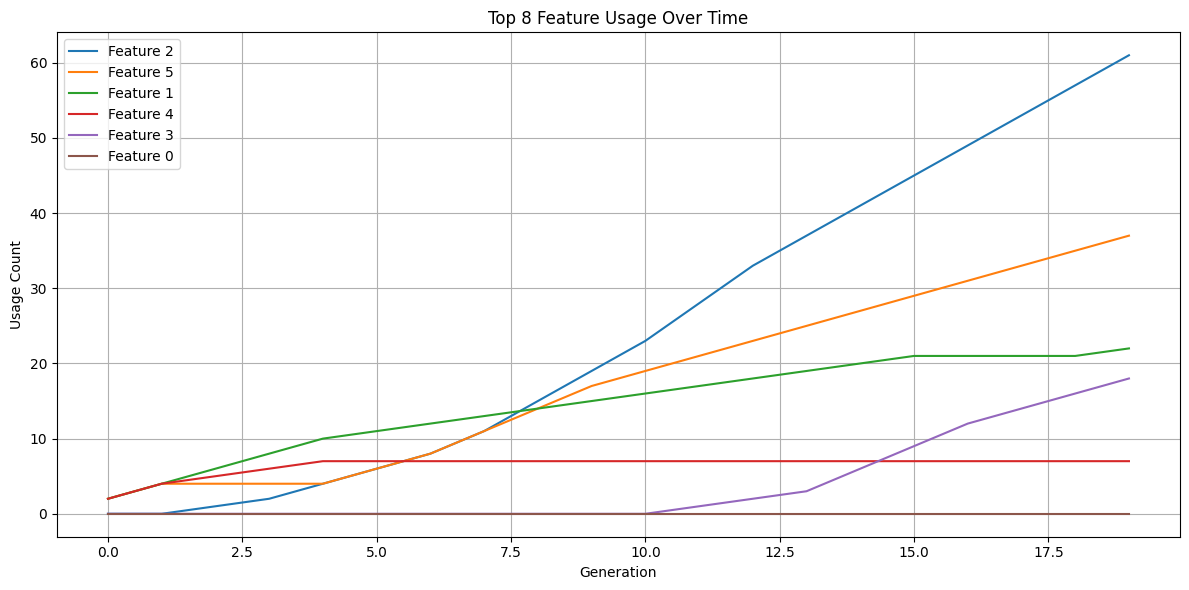

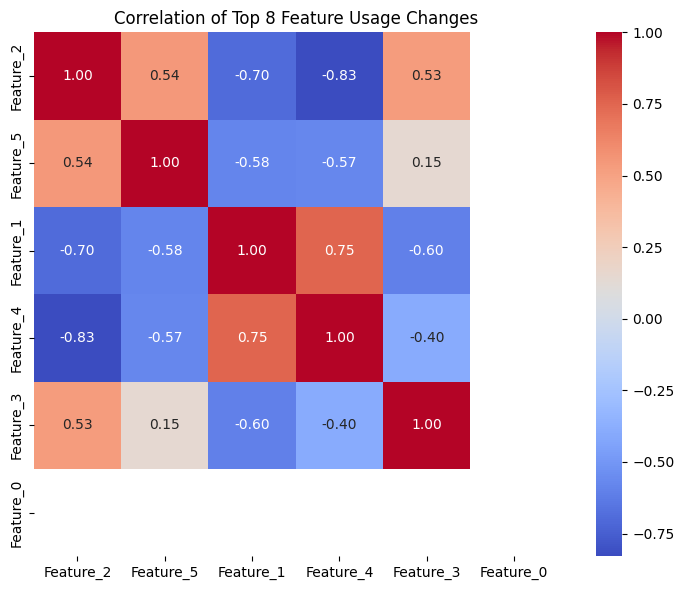

In [3]:

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Charger le fichier CSV avec le bon séparateur
file_path = 'datasets/Audio.xlsx'
df = pd.read_excel(file_path)

# Exemple : transformer les catégories d'âge en classes numériques
age_class_mapping = {
    '[18-25[': 0,
    '[25-35[': 1,
    '[35-45[': 2,
    '[45-55]': 3
}

# Appliquer la transformation
df['age_class_num'] = df['age_class'].map(age_class_mapping)

y = df['age_class_num']

# Supprimer les lignes NaN
mask = ~y.isna()
X = df.loc[mask, 'ampl':'plat_amp'].astype(float)
y = y[mask].astype(int)  # on garde int pour les classes

scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)



evaluator2 = MultiClassClassifier(X_scaled, y)

#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=4, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)
ES_cgp = ES(evaluator2, lam=5,parent_factory=lambda: CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden,config = CGP_config)
best_genome = ES_cgp.evolve(n_generations=10000, early_stopping=1000,early_switch=1000, verbose=True)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Optional: Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- Define classification models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=100000),
    'Ridge Classifier': RidgeClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Classifier': SVC(),
    'KNN Classifier': KNeighborsClassifier()
}

# --- Evaluate accuracy for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Classifier', 'KNN Classifier', 'Ridge Classifier']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
df_results = df_results.sort_values('Accuracy', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)


print("\n=== CGP result ===")
print(f"CGP: accuracy score = {evaluator2.evaluate(best_genome)}")


Logistic Regression: Accuracy = 0.6088
Ridge Classifier: Accuracy = 0.6107
Random Forest: Accuracy = 0.7691
Gradient Boosting: Accuracy = 0.6355
Support Vector Classifier: Accuracy = 0.5992
KNN Classifier: Accuracy = 0.6450

=== Sorted Results ===
                           Accuracy
Random Forest              0.769084
KNN Classifier             0.645038
Gradient Boosting          0.635496
Ridge Classifier           0.610687
Logistic Regression        0.608779
Support Vector Classifier  0.599237

=== CGP result ===
CGP: accuracy score = (0.5888252148997135, 0.6068702290076335)


Starting fitness 0.4546


Early Stop at Gen 9553:  96%|█████████▌| 9553/10000 [2:29:02<06:58,  1.07gen/s]        



Best Train fitness achieved: 0.6213

Test fitness: 0.6145
n10 = mult(x3, x7)
n11 = sum(x6, x6)
n12 = one()
n13 = min(n11, n10)
n14 = sum(n10, n13)
n15 = aminus(x1, x7)
n16 = floor(n11)
n17 = ceil(n13)
n18 = inv(n16)
n19 = const()
n20 = max(n15, n15)
n21 = mult(n15, x7)
n22 = aminus(n12, x1)
n23 = sum(n16, n19)
n24 = gt(n14, x9)
n25 = ceil(n11)
n26 = sum(n10, n19)
n27 = const()
n28 = one()
n29 = abs(x5)
n30 = floor(x1)
n31 = sqrtxy(x8, n24)
n32 = gt(n21, n10)
n33 = sqrtxy(n19, n22)
n34 = abs(n19)
n35 = pow(n15, n21)
n36 = one()
n37 = pow(n15, n14)
n38 = abs(n19)
n39 = mult(n22, n37)
Outputs: n31

Unrolled output expression 0:
sqrtxy(x8, gt(sum(mult(x3, x7), min(sum(x6, x6), mult(x3, x7))), x9))



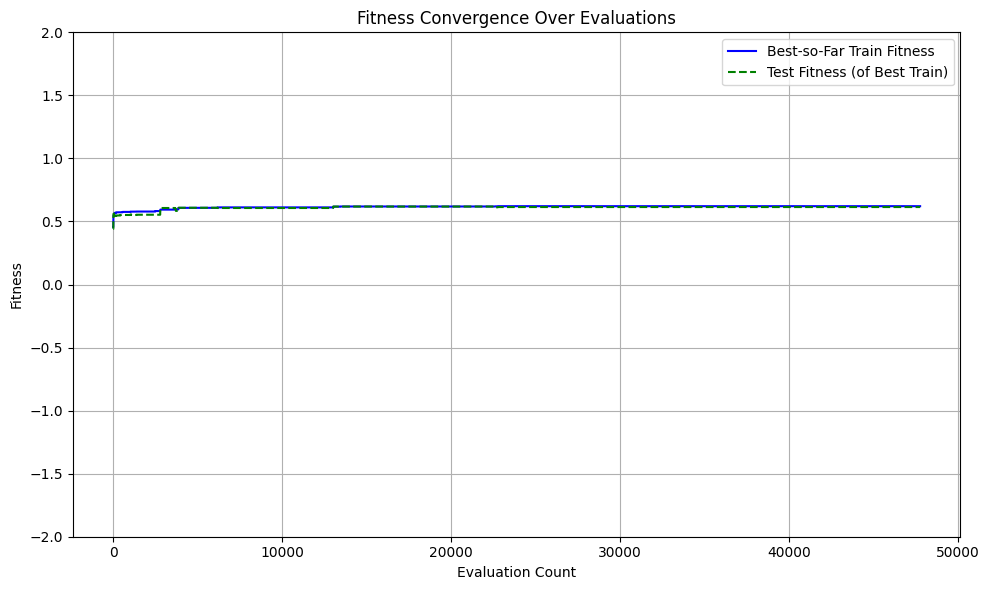

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


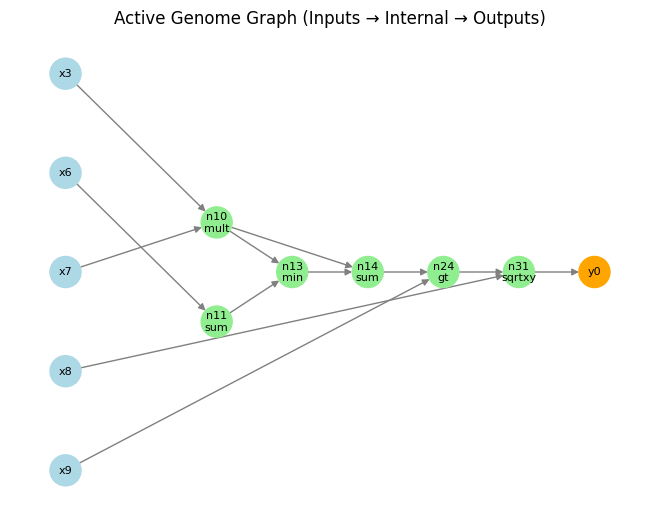

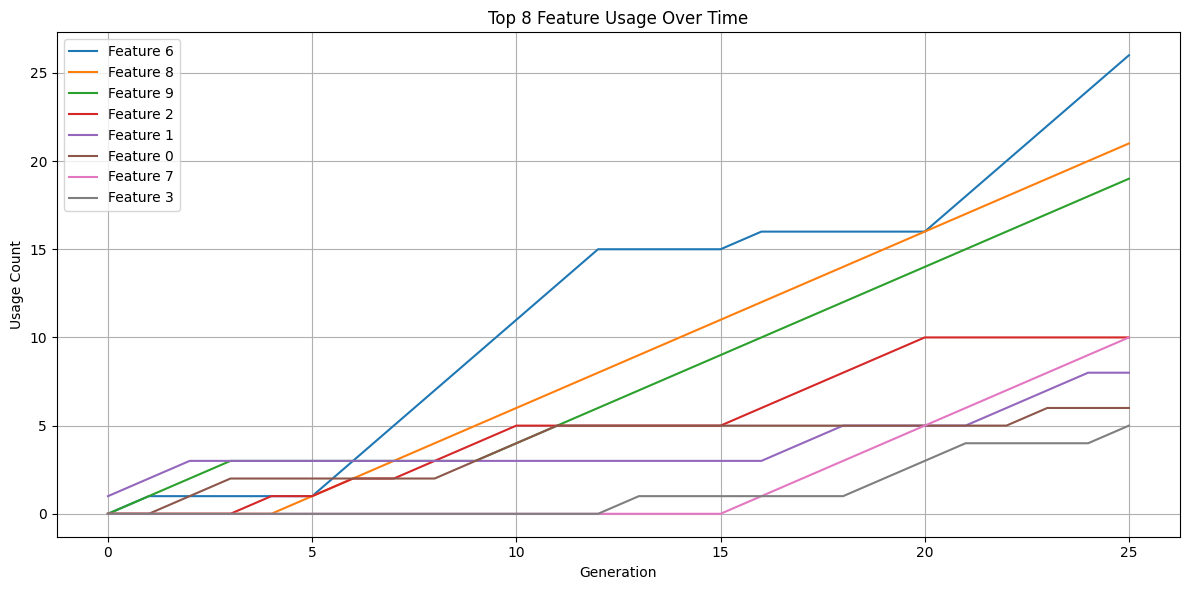

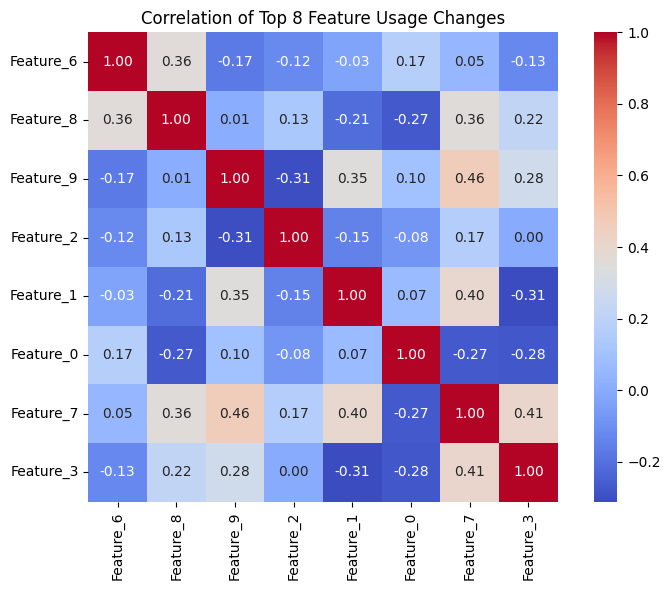

In [3]:

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Charger le fichier CSV avec le bon séparateur
file_path = 'datasets/synth_table_anthr.csv'
df = pd.read_csv(file_path, sep=';')

# Exemple : transformer les catégories d'âge en classes numériques
sex_mapping = {
    'F': 0,
    'M': 1,
}

# Appliquer la transformation
df['sex_num'] = df['sex'].map(sex_mapping)

# Cible
y = df['sex_num']

# Sélection des colonnes freq0 à freq256
X = df.loc[:, 'f_max':'plat_amp'].astype(float)


scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)



evaluator2 = Binary_Classifier(X_scaled, y)

#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=1, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)
ES_cgp = ES(evaluator2, lam=5,parent_factory= lambda: CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden, config= CGP_config)
best_genome = ES_cgp.evolve(n_generations=10000, early_stopping=5000, early_switch=10000, verbose=True, project_name="sex_classif")



In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Optional: Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- Define classification models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=100000),
    'Ridge Classifier': RidgeClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Classifier': SVC(),
    'KNN Classifier': KNeighborsClassifier()
}

# --- Evaluate accuracy for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Classifier', 'KNN Classifier', 'Ridge Classifier']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
df_results = df_results.sort_values('Accuracy', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)


print("\n=== CGP result ===")
print(f"CGP: accuracy score = {evaluator2.evaluate(best_genome)}")


Logistic Regression: Accuracy = 0.6088
Ridge Classifier: Accuracy = 0.6107
Random Forest: Accuracy = 0.7691
Gradient Boosting: Accuracy = 0.6355
Support Vector Classifier: Accuracy = 0.5992
KNN Classifier: Accuracy = 0.6450

=== Sorted Results ===
                           Accuracy
Random Forest              0.769084
KNN Classifier             0.645038
Gradient Boosting          0.635496
Ridge Classifier           0.610687
Logistic Regression        0.608779
Support Vector Classifier  0.599237

=== CGP result ===
CGP: accuracy score = (0.6212989493791786, 0.6145038167938931)
